In [1]:
import pandas as pd 
import yfinance as yf
import matplotlib.pyplot as plt

years = [2019]
temp = []

# Pegando retornos pros portfólios
for year in years:
    temp.append(pd.read_parquet(f"../../data/02_clean/returns_{str(year)}.parquet"))

returns = pd.concat(temp)

modes = ["fast", "medium", "slow"]
centralities = ["central", "peripheral"]
returns_dict = {}

for centrality in centralities:
    for mode in modes:
        tickers = pd.read_csv(f"../../data/07_portfolios_metadata/beta_df.csv")
        tickers = tickers[tickers["portfolio"]==f"{centrality} {mode}"]["Ticker"]
        returns_dict[f"{centrality} {mode}"] = returns[tickers]

sp500_dr = yf.download(tickers="^GSPC", start=f"{str(years[0])}-01-01", end=f"{str(years[-1])}-12-31")["Close"].pct_change()[1:]
sp500_dr.columns = ["rm"]

[*********************100%***********************]  1 of 1 completed


## Equally weighted portfolio

In [2]:
cum_ret = {}

for portfolio_name, ret in returns_dict.items():
    cr = (1 + ret.mean(axis=1)).cumprod()
    cum_ret[portfolio_name] = cr / cr.iloc[0]

cum_ret["sp500"] = (1 + sp500_dr).cumprod()
cum_ret["sp500"] = cum_ret["sp500"] / cum_ret["sp500"].iloc[0]

In [3]:
returns_dict

{'central fast': Ticker          ABTC      ABVC       ACB      ACET      ACTG       AHG  \
 Date                                                                     
 2019-01-03  0.000000 -0.047619 -0.019084 -0.068539 -0.032258  0.026087   
 2019-01-04  0.000000  0.000000  0.015564  0.059107 -0.003333  0.067797   
 2019-01-07  0.000000  0.000000  0.007663  0.014806  0.026756  0.071429   
 2019-01-08  0.002970  0.000000 -0.043726 -0.048260  0.022801  0.129630   
 2019-01-09  0.000000  0.000000  0.083499  0.020047 -0.003185 -0.022951   
 ...              ...       ...       ...       ...       ...       ...   
 2019-12-24 -0.061905 -0.018868 -0.009950  0.014493  0.022989  0.000000   
 2019-12-26  0.115482  0.000000  0.005025 -0.050000  0.003745  0.011957   
 2019-12-27 -0.056883 -0.009615 -0.045000 -0.007519 -0.003731  0.042965   
 2019-12-30 -0.026538 -0.019417  0.000000  0.015152  0.000000  0.004119   
 2019-12-31  0.044610 -0.134653  0.130890  0.111940 -0.003745 -0.041026   
 
 Ticker

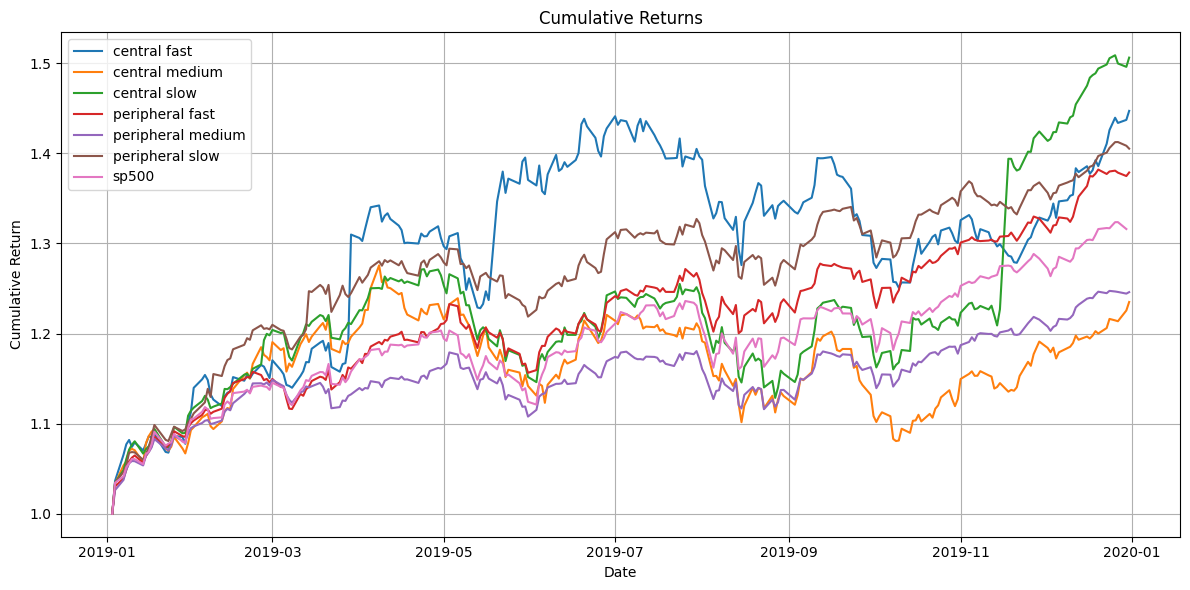

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for name, series in cum_ret.items():
    plt.plot(series.index, series, label=name)

plt.legend()
plt.title("Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)

plt.tight_layout()
plt.show()

## Mcap weighted portfolio

In [5]:
import numpy as np

temp = pd.read_csv("../../data/07_portfolios_metadata/beta_df.csv")
mcap = pd.read_csv("../../data/07_portfolios_metadata/all_tickers_complete_metadata.csv")[["Ticker", "mcap_2019"]]

mcap["mcap_2019"] = (
    mcap["mcap_2019"]
    .replace("#ERROR!", np.nan)
    .str.replace(".", "", regex=False)   # remove separador de milhar
    .str.replace(",", ".", regex=False)  # converte decimal
)
mcap["mcap_2019"] = pd.to_numeric(mcap["mcap_2019"])

mcap = mcap.merge(
    temp, how="left", on="Ticker"
).drop(columns=["beta_2019"])

mcap["weight"] = (
    mcap["mcap_2019"] /
    mcap.groupby("portfolio")["mcap_2019"].transform("sum")
)

In [6]:
cum_ret = {}

for centrality in centralities:
    for mode in modes:
        w = mcap[mcap["portfolio"]==f"{centrality} {mode}"].set_index("Ticker")["weight"]
        r = returns_dict[f"{centrality} {mode}"]

        cum_ret[f"{centrality} {mode}"] = (1 + (w * r).sum(axis=1)).cumprod()

cum_ret["sp500"] = (1 + sp500_dr).cumprod()
cum_ret["sp500"] = cum_ret["sp500"] / cum_ret["sp500"].iloc[0]

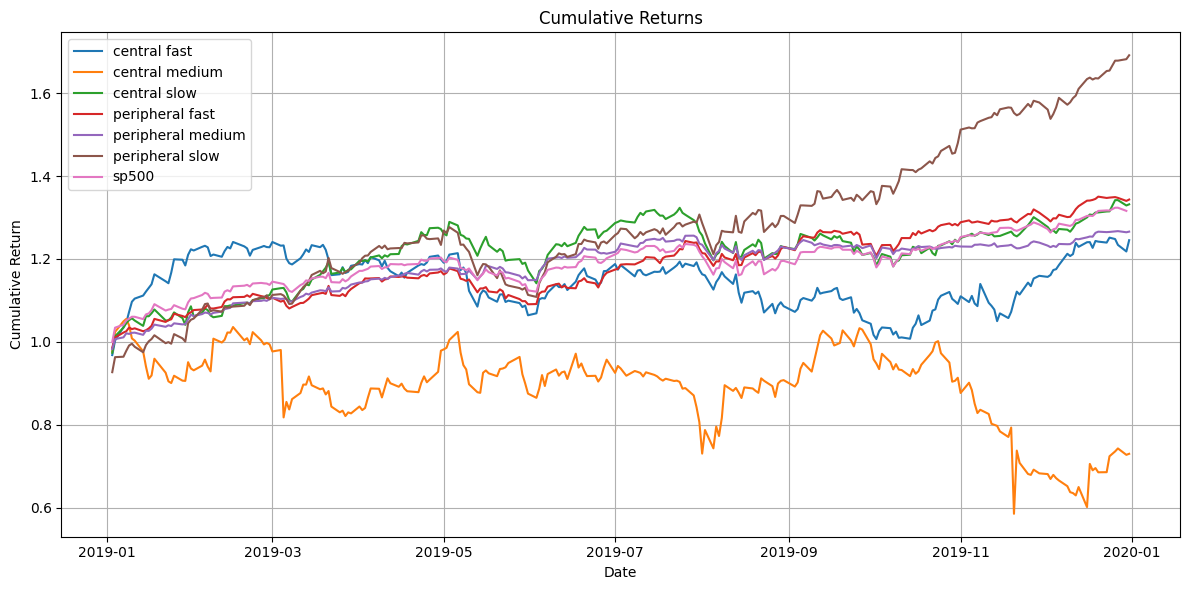

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for name, series in cum_ret.items():
    plt.plot(series.index, series, label=name)

plt.legend()
plt.title("Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)

plt.tight_layout()
plt.show()

In [8]:
pd.read_csv(f"../../data/07_portfolios_metadata/central_fast_metadata.csv")

,Ticker,No.,Company,Sector,Industry,Country,Market Cap,P/E,Price,Change,Volume
0,ABTC,32,American Bitcoin Corp,Financial,Capital Markets,USA,1.490000e+09,NaN,1.61,-2.42,7330506
1,ABVC,35,ABVC BioPharma Inc,Healthcare,Biotechnology,USA,5.079000e+07,NaN,2.09,2.96,52462
2,ACB,39,Aurora Cannabis Inc,Healthcare,Drug Manufacturers - Specialty & Generic,Canada,3.073100e+08,NaN,5.42,5.86,2202085
3,ACET,43,Adicet Bio Inc,Healthcare,Biotechnology,USA,7.278000e+07,NaN,0.47,-4.06,1585658
4,ACTG,61,Acacia Research Corp,Industrials,Business Equipment & Supplies,USA,3.708300e+08,77.35,3.84,1.70,92206
...,...,...,...,...,...,...,...,...,...,...,...
149,XBIO,4389,Xenetic Biosciences Inc,Healthcare,Biotechnology,USA,5.090000e+06,NaN,2.22,-4.72,8072
150,XOMA,4410,XOMA Royalty Corp,Healthcare,Biotechnology,USA,3.254300e+08,35.25,26.28,3.10,48987
151,XXII,4432,22nd Century Group Inc,Consumer Defensive,Tobacco,USA,7.110000e+06,NaN,1.02,6.00,72043
152,Z,4464,Zillow Group Inc,Communication Services,Internet Content & Information,USA,1.692000e+10,NaN,70.25,2.73,1644143


In [9]:
temp = pd.read_csv("../../data/07_portfolios_metadata/beta_df.csv")
temp[temp["Ticker"]=="AACG"]

,portfolio,Ticker,beta_2019
285,central slow,AACG,0.00536
